# Step 1: Load and explore the California Housing dataset

This step loads the built-in California Housing dataset, converts it to a pandas DataFrame, adds the target column MedHouseVal, prints the shape and summary, then visualizes relationships. The lab also asks you to rank correlations with the target, plot the target distribution, and say how many samples there are.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target   # target in $100,000s

# Explore
print("Dataset shape:", df.shape)
print("\nFeature names:")
print(housing.feature_names)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

# Visualize relationships

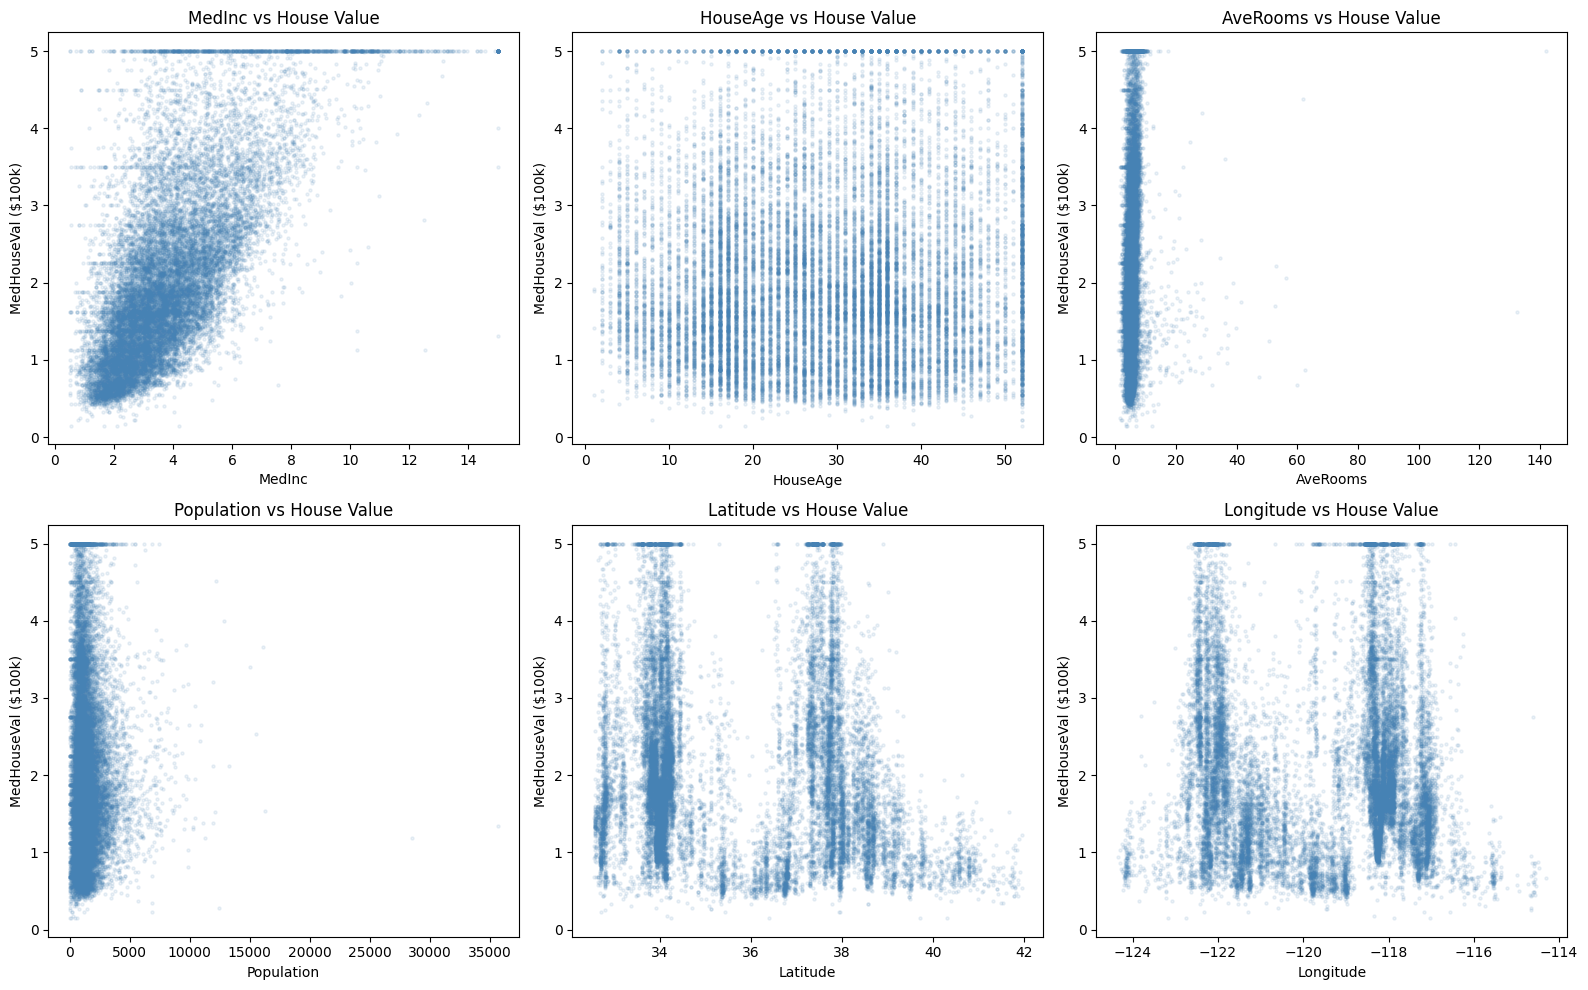

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

# Task 1 code

Correlation with target:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


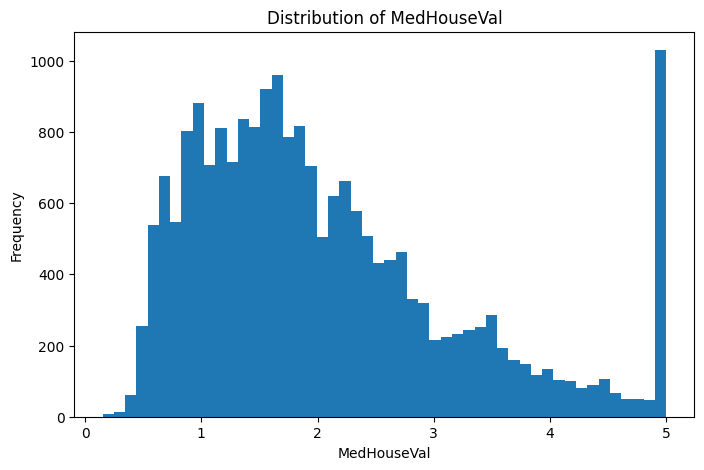

Number of samples: 20640


In [12]:
print("Correlation with target:")
print(df.corr()['MedHouseVal'].sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.title("Distribution of MedHouseVal")
plt.show()

print("Number of samples:", df.shape[0])

MedInc usually has the strongest positive correlation with MedHouseVal. The dataset has 20,640

---

samples and 8 features, so after adding the target column the DataFrame shape becomes (20640, 9). The target is not perfectly normal and shows a cap near 5.0, which the lab specifically asks you to notice.

# Step 2: Build a simple linear regression model with one feature

The PDF says to start with the simplest case: predict house value using only MedInc, split the data 80/20, train LinearRegression, print slope and intercept, then draw the regression line. It also asks you to predict the value at MedInc = 5.0 and compare with a simple model using HouseAge.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Use only MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Parameters
print(f"Slope (w1): {model_simple.coef_[0]:.4f}")
print(f"Intercept (w0): {model_simple.intercept_:.4f}")
print(f"Equation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})")

Training samples: 16512
Testing samples: 4128
Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + (0.4446)


# Plot the regression line

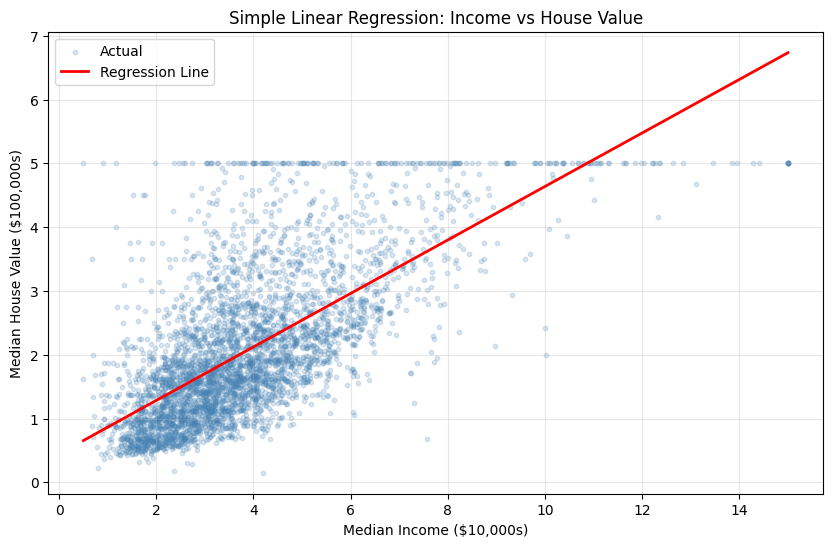

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10, color='steelblue', label='Actual')

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 2 code

In [15]:
pred_5 = model_simple.predict([[5.0]])
print("Prediction for MedInc = 5.0:", pred_5[0])

Prediction for MedInc = 5.0: 2.5412897613814236


# Compare with HouseAge

In [16]:
X_age = df[['HouseAge']].values

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

y_pred_age = model_age.predict(X_test_age)

print("HouseAge model R^2:", r2_score(y_test_age, y_pred_age))
print("HouseAge model RMSE:", np.sqrt(mean_squared_error(y_test_age, y_pred_age)))

HouseAge model R^2: 0.012551235533311389
HouseAge model RMSE: 1.1375243850177597


Write the equation exactly using your slope and intercept. For MedInc = 5.0, substitute into the equation by hand, then verify with model_simple.predict([[5.0]]). The HouseAge model is usually worse because house prices depend more strongly on income than on age alone.

---



# Step 3: Evaluate the simple model
The lab says to use MSE, RMSE, MAE, and R² for evaluation, then create a predicted-vs-actual plot and a residual plot. It also explains that R² shows how much variance is explained, and RMSE is in the original target units.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict
y_pred_simple = model_simple.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE:  {mae:.4f} (error in $100,000s)")
print(f"R^2:  {r2:.4f} ({r2*100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE:  0.7091
RMSE: 0.8421 (error in $100,000s)
MAE:  0.6299 (error in $100,000s)
R^2:  0.4589 (45.9% variance explained)


# Predicted vs actual and residuals

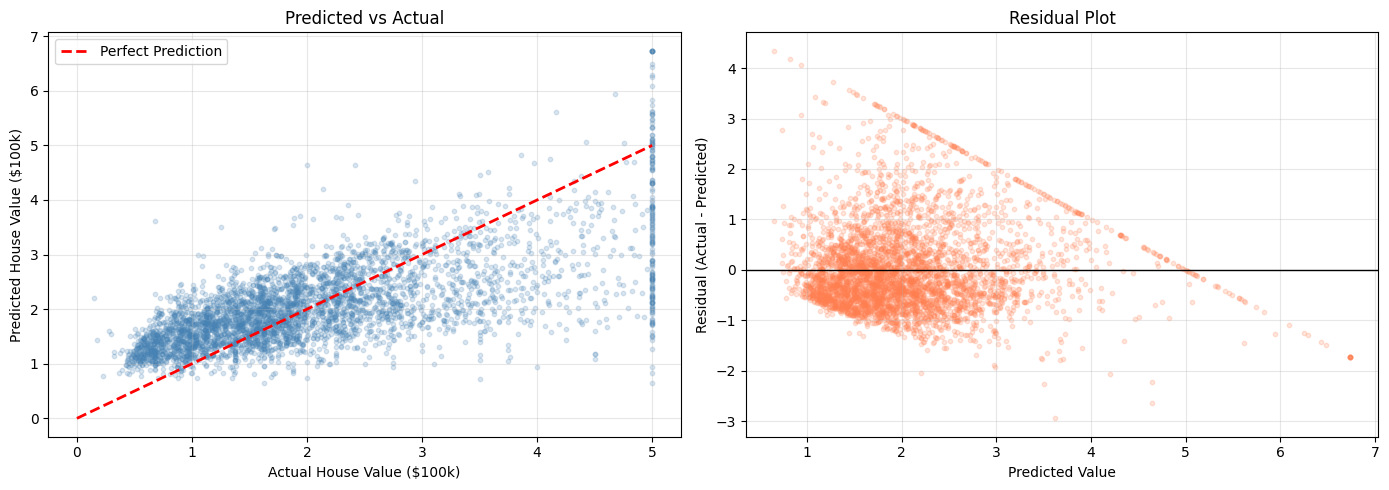

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# task 3

If RMSE is about 0.74, then the typical error is about 0.74 × 100,000 = $74,000. If points are far from the diagonal at high values, the model struggles more with expensive houses. A single feature helps, but it is not enough to explain house prices well. The residual plot should ideally look random around zero; patterns suggest a linear model is missing something.

---



# Step 4: Train multiple linear regression with all features

The PDF next uses all 8 features, scales them with StandardScaler, fits LinearRegression inside a pipeline, then compares performance against the simple model. It also asks you to inspect feature importance using the scaled coefficients.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# All features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
mae_multi = mean_absolute_error(y_test, y_pred_multi)

print("=== Multiple Linear Regression (all 8 features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"MAE:  {mae_multi:.4f}")
print(f"R^2:  {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)")
print(f"Improvement over simple model: {r2:.4f} -> {r2_multi:.4f}")

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
MAE:  0.5332
R^2:  0.5758 (57.6% variance explained)
Improvement over simple model: 0.4589 -> 0.5758


# Feature importance

In [20]:
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


# Plot coefficients

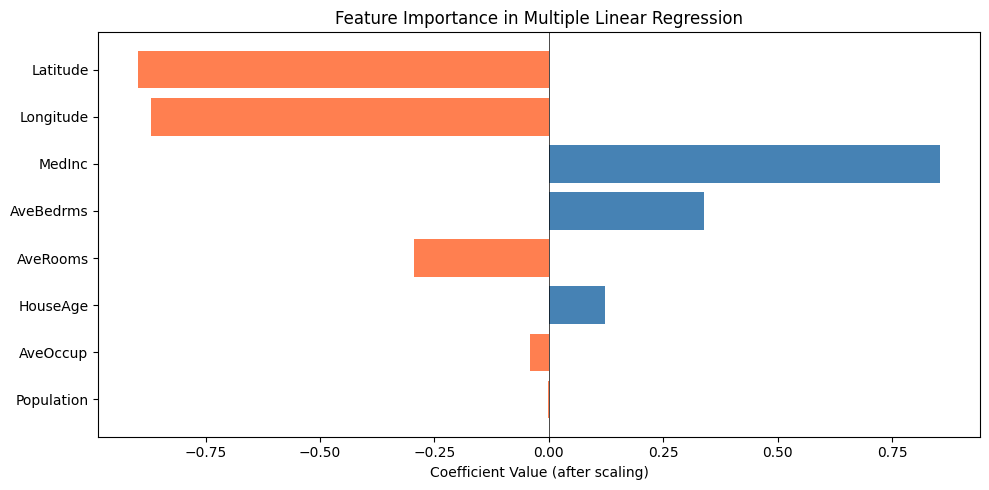

In [21]:
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Predicted vs actual for the multiple model

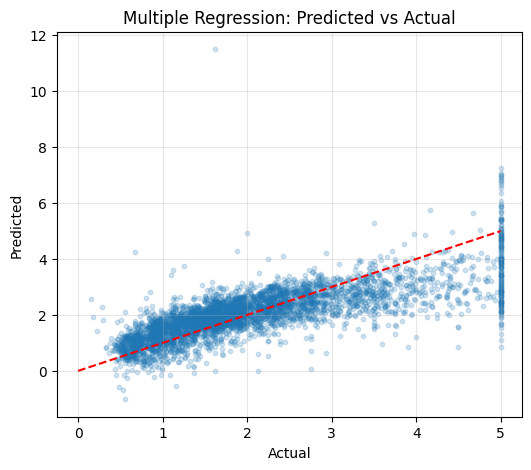

In [22]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10)
plt.plot([0,5], [0,5], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression: Predicted vs Actual")
plt.grid(True, alpha=0.3)
plt.show()

# task 4

List the top 3 and bottom 3 features from coef_df. Because scaling makes all features comparable, a larger absolute coefficient means more influence. A negative latitude coefficient can make geographic sense in California because moving north is often associated with lower prices in many districts, after controlling for other variables. The predicted-vs-actual plot for the multiple model should look closer to the diagonal than the simple model.

---



# Step 5: Try polynomial regression
The lab then asks you to try polynomial regression on MedInc with degrees 1, 2, and 3, and then on all features with degree 2. It also warns about feature explosion and overfitting.

# Single-feature polynomial regression

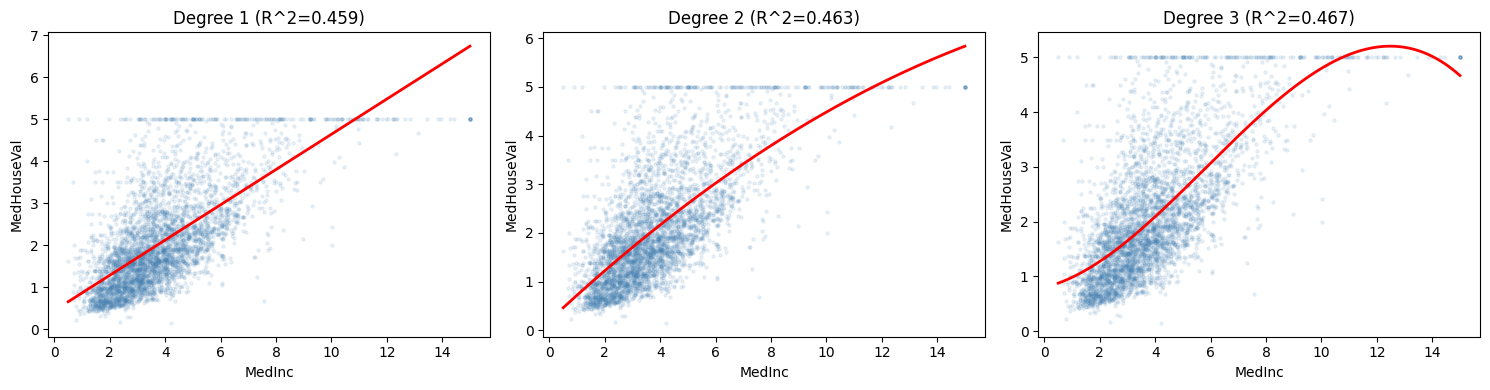

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2 = 0.4589, RMSE = 0.8421
Degree 2: R^2 = 0.4633, RMSE = 0.8386
Degree 3: R^2 = 0.4671, RMSE = 0.8356


In [23]:
from sklearn.preprocessing import PolynomialFeatures

X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R^2={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

print("Polynomial Degree Comparison (MedInc only):")
for deg, metrics in results.items():
    print(f"Degree {deg}: R^2 = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")

# Degree 2 on all features

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print("=== Polynomial Regression (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE:  {mae_poly:.4f}")
print(f"R^2:  {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)")

poly_features = pipe_poly_all.named_steps['poly']
print("Original features: 8")
print("After degree-2 expansion:", poly_features.n_output_features_)

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
MAE:  0.4670
R^2:  0.6457 (64.6% variance explained)
Original features: 8
After degree-2 expansion: 44


# Optional: degree 5 overfitting check

In [25]:
pipe_poly5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly5.fit(X_train_s, y_train)
y_pred_5 = pipe_poly5.predict(X_test_s)

print("Degree 5 single-feature R^2:", r2_score(y_test, y_pred_5))
print("Degree 5 single-feature RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_5)))

Degree 5 single-feature R^2: 0.46679559272641336
Degree 5 single-feature RMSE: 0.8358922433716712


# task 5

Degree 2 or 3 often captures the relationship better than degree 1 for MedInc, but higher degrees can start behaving strangely at the edges. That is overfitting. Degree 2 on 8 original features expands to many more features, which increases flexibility but also increases risk of overfitting.

---



# Step 6: Train regularized models

The PDF next asks you to train Ridge, Lasso, and ElasticNet using pipelines with scaling, then compare RMSE, MAE, and R². It also explains the role of each regularization method: Ridge shrinks all weights, Lasso can push some to zero, and ElasticNet combines both.

In [26]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

print(f"{'Model':<28} {'RMSE':>8} {'MAE':>8} {'R^2':>8}")
print("-" * 56)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    results_dict[name] = {'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v}
    print(f"{name:<28} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


# Compare coefficients

In [27]:
coef_compare = pd.DataFrame({'Feature': feature_names})

for name, pipe in models.items():
    model = pipe.named_steps['model']
    coef_compare[name] = model.coef_

print(coef_compare)

      Feature  LinearRegression  Ridge (alpha=1.0)  Lasso (alpha=0.01)  \
0      MedInc          0.854383           0.854327            0.800957   
1    HouseAge          0.122546           0.122624            0.127087   
2    AveRooms         -0.294410          -0.294210           -0.162759   
3   AveBedrms          0.339259           0.339008            0.206207   
4  Population         -0.002308          -0.002282           -0.000000   
5    AveOccup         -0.040829          -0.040833           -0.030602   
6    Latitude         -0.896929          -0.896168           -0.790113   
7   Longitude         -0.869842          -0.869071           -0.755674   

   ElasticNet (alpha=0.01)  
0                 0.823963  
1                 0.130005  
2                -0.216074  
3                 0.256299  
4                -0.000000  
5                -0.035948  
6                -0.788420  
7                -0.757036  


# task 6

Regularization helps control overfitting, especially when the model has many features or polynomial terms. Ridge keeps all features but shrinks weights, Lasso can eliminate some by setting them near zero, and ElasticNet balances both behaviors.

---



# Step 7: Alpha tuning experiment for Ridge
The lab includes a Ridge alpha search to see how regularization strength changes performance. It explains that larger alpha means stronger regularization and simpler models.

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
alpha_results = []

for a in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a, random_state=42))
    ])

    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)

    rmse_a = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_a = r2_score(y_test, y_pred)

    alpha_results.append({'alpha': a, 'RMSE': rmse_a, 'R2': r2_a})

alpha_df = pd.DataFrame(alpha_results)
print(alpha_df)

# Plot alpha tuning

In [33]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
alpha_results = []

for a in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a, random_state=42))
    ])

    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)

    rmse_a = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_a = r2_score(y_test, y_pred)

    alpha_results.append({'alpha': a, 'RMSE': rmse_a, 'R2': r2_a})

alpha_df = pd.DataFrame(alpha_results)
print(alpha_df)

     alpha      RMSE        R2
0    0.001  0.745581  0.575788
1    0.010  0.745581  0.575788
2    0.100  0.745579  0.575791
3    1.000  0.745557  0.575816
4   10.000  0.745342  0.576060
5  100.000  0.743819  0.577791


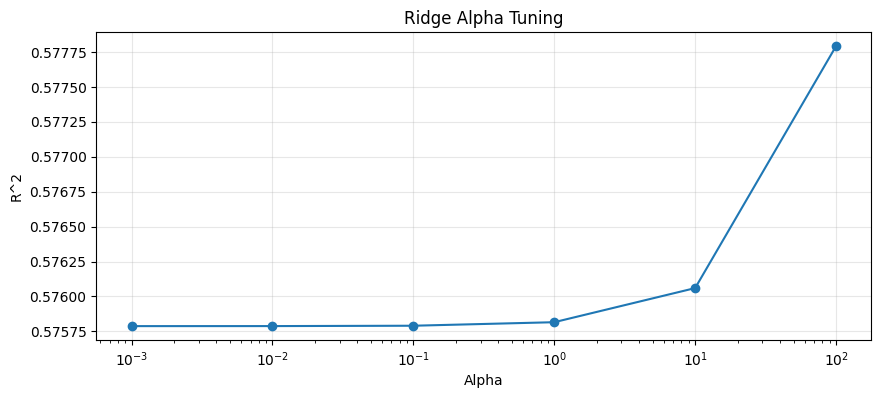

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(alpha_df['alpha'], alpha_df['R2'], marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R^2")
plt.title("Ridge Alpha Tuning")
plt.grid(True, alpha=0.3)
plt.show()

# task 7

pick the alpha with the best tradeoff between low RMSE and high R². Very small alpha behaves like regular linear regression; very large alpha may oversimplify the model.

---



# Step 8: Final model comparison

The lab then asks for a comparison table with model name, RMSE, MAE, R², and number of effective features, followed by visual comparison charts.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load dataset to ensure df is defined
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# All features and target for California Housing data
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),

    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),

    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),

    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

# Evaluate all models
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []

for name, pipe in all_models.items():

    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]]   # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    # Fit and predict
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    # Metrics
    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    # Save results
    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    # Print row
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data)

print("\nComparison Table:")
print(comparison_df)

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8

Comparison Table:
                Model      RMSE       MAE        R2  Features
0  Simple LR (MedInc)  0.842090  0.629909  0.458859         1
1   Multiple LR (all)  0.745581  0.533200  0.575788         8
2  Polynomial (deg=2)  0.681397  0.467001  0.645682        44
3               Ridge  0.745557  0.533193  0.575816         8
4               Lasso  0.740442  0.535326  0.581615         8
5          ElasticNet  0.741588  0.534077  0.580319         8


# Visual Comparison

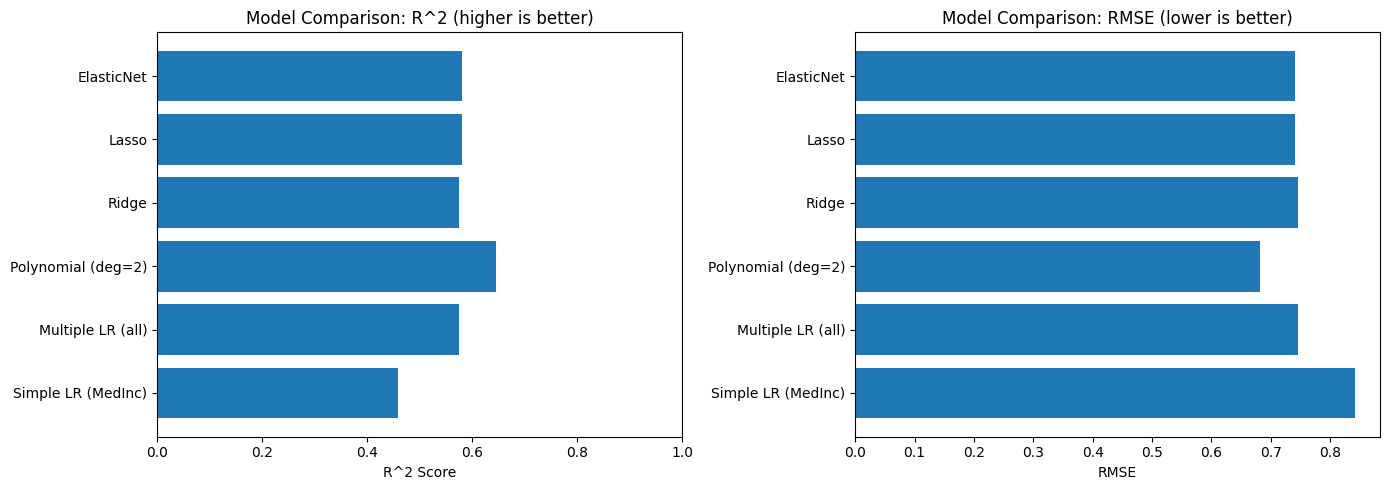

In [9]:
import matplotlib.pyplot as plt
comp_df = pd.DataFrame(comparison_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comparison_df['Model'], comparison_df['R2'])
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comparison_df['Model'], comparison_df['RMSE'])
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

# task 8

Choose the model with the best balance of high R² and low RMSE, not just the most complex one. If polynomial degree 2 improves performance only slightly but adds many more features, you can say the extra complexity may not be worth it.

---



# Step 9: Saudi Housing challenge

The last big section of the lab asks you to apply the same workflow to a new dataset, saudi_housing.csv, including one-hot encoding the city column, training a simple model, then a multiple model, then regularized models, then building a comparison table.

In [12]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 500
cities = np.random.choice(
['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
n, p=[0.30, 0.30, 0.15, 0.15, 0.10])
# Base price varies by city (in SAR thousands)
city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650,
'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)
area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])
# Generate price with realistic relationships
price = (base
+ 3.5 * area
+ 80 * bedrooms
+ 50 * bathrooms- 12 * age
+ 15 * floor
+ 100 * has_parking
+ np.random.normal(0, 150, n)) # noise
price = np.round(np.maximum(price, 200), 1)
df_saudi = pd.DataFrame({
'city': cities,
'area_sqm': area,
'bedrooms': bedrooms,
'bathrooms': bathrooms,
'age_years': age,
'floor': floor,
'has_parking': has_parking,
'price_kSAR': price # price in thousands of SAR
})
df_saudi.to_csv('saudi_housing.csv', index=False)
print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print(f'\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

# task 9

## step 1,2

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define features (X) and target (y)
X = df_saudi.drop(columns=['price_kSAR'])
y = df_saudi['price_kSAR']

# Identify categorical and numerical features
categorical_features = ['city']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


Original X shape: (500, 7)
Original y shape: (500,)
Training samples: 400
Testing samples: 100
Categorical features: ['city']
Numerical features: ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']


## Step 3: Simple Linear Regression with `area_sqm`

Simple Linear Regression (area_sqm only) R^2: 0.4932


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


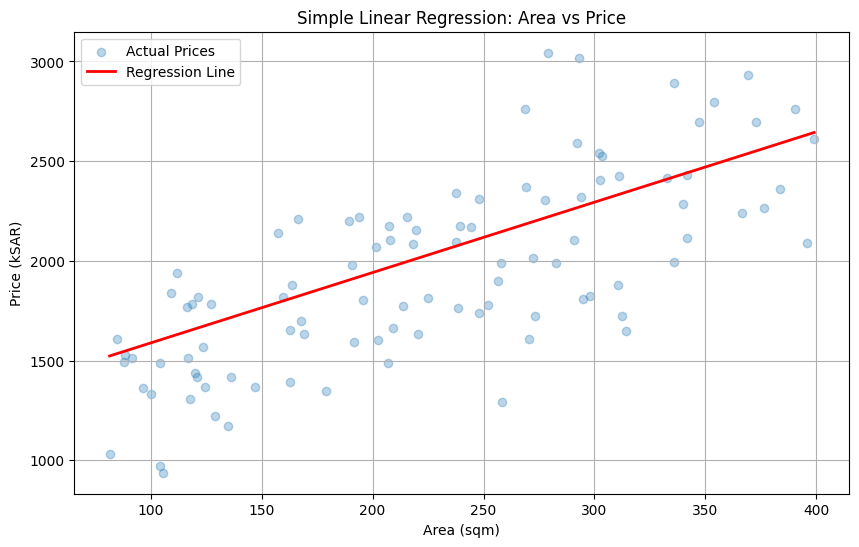

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Extract only 'area_sqm' for the simple model
X_simple_saudi = df_saudi[['area_sqm']]
y_simple_saudi = df_saudi['price_kSAR']

# Split data for the simple model
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple_saudi, y_simple_saudi, test_size=0.2, random_state=42
)

# Create a pipeline for scaling and linear regression
pipeline_simple_saudi = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regressor', LinearRegression())
])

# Train the model
pipeline_simple_saudi.fit(X_train_simple, y_train_simple)

# Make predictions
y_pred_simple_saudi = pipeline_simple_saudi.predict(X_test_simple)

# Calculate R^2 score
r2_simple_saudi = r2_score(y_test_simple, y_pred_simple_saudi)
print(f"Simple Linear Regression (area_sqm only) R^2: {r2_simple_saudi:.4f}")

# Plot the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test_simple, alpha=0.3, label='Actual Prices')
x_plot = np.linspace(X_test_simple.min(), X_test_simple.max(), 100).reshape(-1, 1)
y_plot = pipeline_simple_saudi.predict(x_plot)
plt.plot(x_plot, y_plot, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()
plt.grid(True)
plt.show()

## Step 4: Multiple Linear Regression with all features

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create a pipeline with the preprocessor and Linear Regression model
pipe_multi_saudi = Pipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('linear_regressor', LinearRegression())
])

# Train the model
pipe_multi_saudi.fit(X_train, y_train)

# Make predictions
y_pred_multi_saudi = pipe_multi_saudi.predict(X_test)

# Calculate metrics
rmse_multi_saudi = np.sqrt(mean_squared_error(y_test, y_pred_multi_saudi))
mae_multi_saudi = mean_absolute_error(y_test, y_pred_multi_saudi)
r2_multi_saudi = r2_score(y_test, y_pred_multi_saudi)

print("=== Multiple Linear Regression (all features, Saudi Housing) ===")
print(f"RMSE: {rmse_multi_saudi:.4f}")
print(f"MAE:  {mae_multi_saudi:.4f}")
print(f"R^2:  {r2_multi_saudi:.4f} ({r2_multi_saudi*100:.1f}% variance explained)")
print(f"Improvement over simple model: {r2_simple_saudi:.4f} -> {r2_multi_saudi:.4f}")

=== Multiple Linear Regression (all features, Saudi Housing) ===
RMSE: 173.0295
MAE:  137.3012
R^2:  0.8645 (86.5% variance explained)
Improvement over simple model: 0.4932 -> 0.8645


## Step 5: Train Regularized Models (Ridge, Lasso, ElasticNet)

In [23]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models_saudi = {
    'LinearRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=42)) # Default alpha=1.0
    ]),
    'Lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.01, random_state=42)) # A small alpha to allow some feature selection
    ]),
    'ElasticNet': Pipeline([
        ('preprocessor', preprocessor),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)) # A small alpha and l1_ratio=0.5
    ]),
}

print(f"{'Model':<18} {'RMSE':>8} {'MAE':>8} {'R^2':>8}")
print("-" * 45)

results_saudi = {}

for name, pipe in models_saudi.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    results_saudi[name] = {'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v}
    print(f"{name:<18} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f}")

Model                  RMSE      MAE      R^2
---------------------------------------------
LinearRegression   173.0295 137.3012   0.8645
Ridge              173.2235 137.4361   0.8642
Lasso              173.0361 137.3098   0.8645
ElasticNet         173.4695 137.7345   0.8638


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.751e+04, tolerance: 7.862e+03
  model = cd_fast.enet_coordinate_descent(


## Step 6: Feature importance from Lasso model

Lasso Model Feature Importance (absolute coefficients):
     Feature  Coefficient
    area_sqm   333.999178
 city_Dammam  -262.903018
 city_Makkah   251.454784
    bedrooms   142.302329
city_Madinah  -135.466034
   age_years  -128.050074
       floor    74.013731
   bathrooms    53.944303
 has_parking    42.221953
 city_Jeddah   -37.071745
 city_Riyadh    14.934245


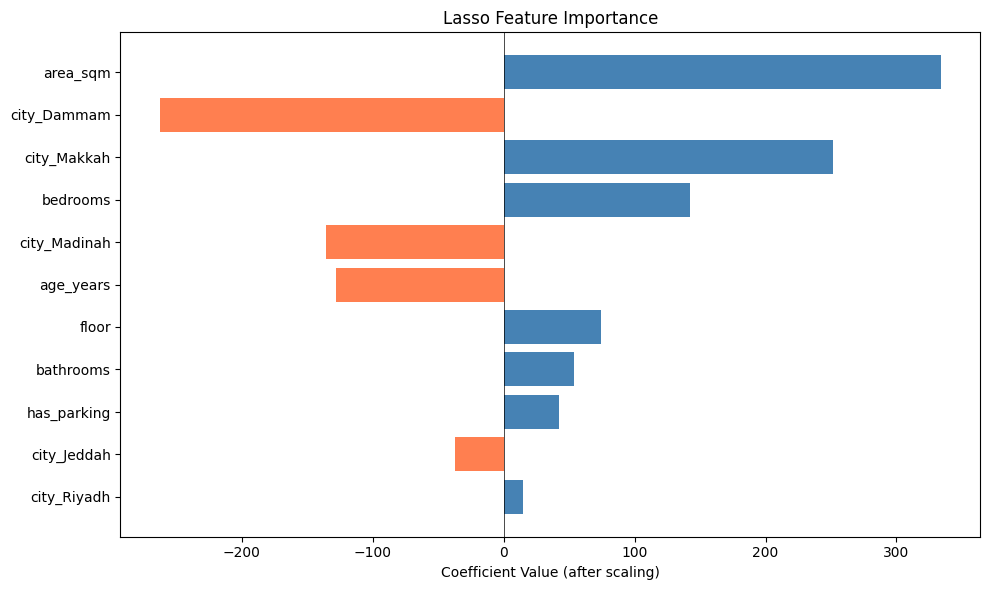

In [24]:
# Extract the Lasso model from the pipeline
lasso_pipeline = models_saudi['Lasso']
lasso_model = lasso_pipeline.named_steps['model']

# Get feature names from the preprocessor
# Numerical features
feature_names_processed = numerical_features
# Categorical features (one-hot encoded)
categorical_feature_names = lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names_processed = np.concatenate([feature_names_processed, categorical_feature_names])

# Create a DataFrame for coefficients
coef_df_lasso = pd.DataFrame({
    'Feature': feature_names_processed,
    'Coefficient': lasso_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Lasso Model Feature Importance (absolute coefficients):")
print(coef_df_lasso.to_string(index=False))

# Plot coefficients
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df_lasso['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df_lasso['Feature'], coef_df_lasso['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Lasso Feature Importance')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 7: Comparison table and identification of the best model


Saudi Housing Model Comparison Table:
                  Model        RMSE         MAE        R2
0  Simple LR (area_sqm)  334.666127  276.058355  0.493164
1     Multiple LR (all)  173.029522  137.301214  0.864517
2      LinearRegression  173.029522  137.301214  0.864517
3                 Ridge  173.223528  137.436119  0.864213
4                 Lasso  173.036130  137.309829  0.864507
5            ElasticNet  173.469465  137.734487  0.863827

Model with highest R^2:
Model    Multiple LR (all)
RMSE            173.029522
MAE             137.301214
R2                0.864517
Name: 1, dtype: object

Model with lowest RMSE:
Model    Multiple LR (all)
RMSE            173.029522
MAE             137.301214
R2                0.864517
Name: 1, dtype: object


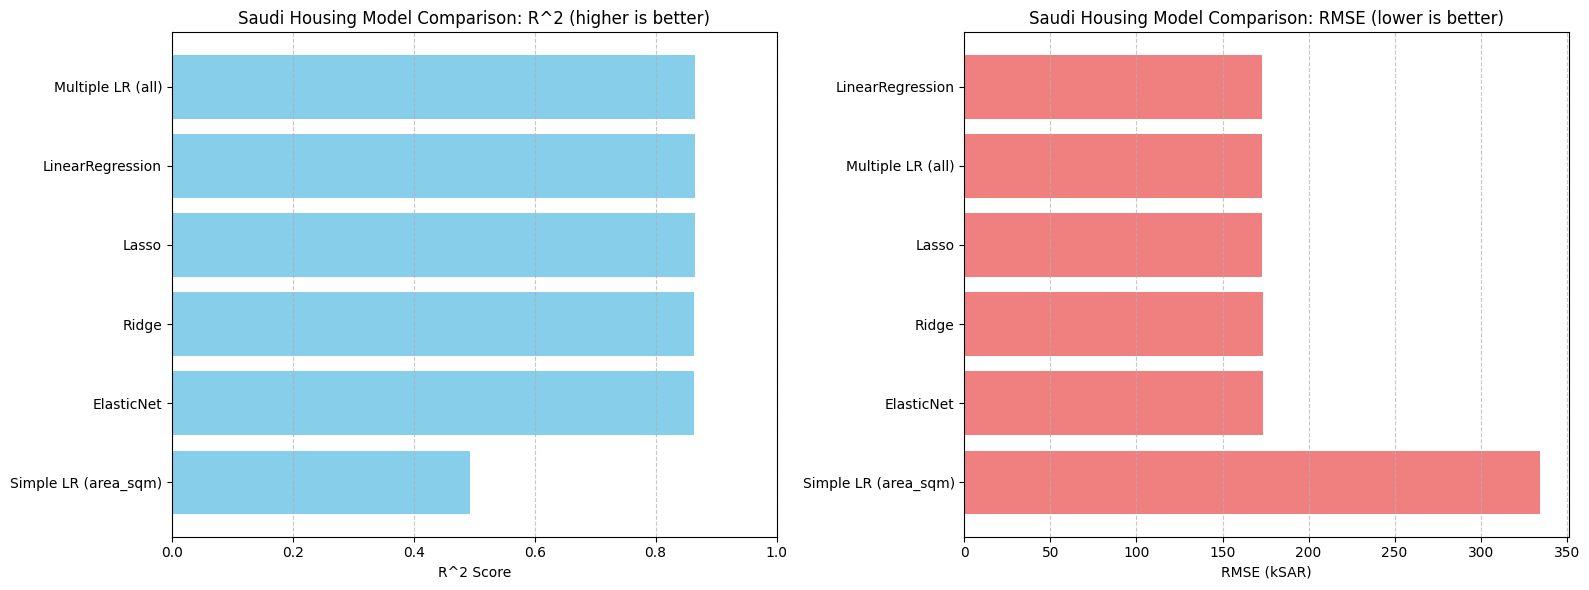

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for the comparison table
comparison_data_saudi = []

# Add simple LR model results
comparison_data_saudi.append({
    'Model': 'Simple LR (area_sqm)',
    'RMSE': np.sqrt(mean_squared_error(y_test_simple, y_pred_simple_saudi)),
    'MAE': mean_absolute_error(y_test_simple, y_pred_simple_saudi),
    'R2': r2_simple_saudi
})

# Add multiple LR model results
comparison_data_saudi.append({
    'Model': 'Multiple LR (all)',
    'RMSE': rmse_multi_saudi,
    'MAE': mae_multi_saudi,
    'R2': r2_multi_saudi
})

# Add regularized models results from results_saudi dictionary
for name, metrics in results_saudi.items():
    comparison_data_saudi.append({
        'Model': name,
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'R2': metrics['R2']
    })

comparison_df_saudi = pd.DataFrame(comparison_data_saudi)

print("\nSaudi Housing Model Comparison Table:")
print(comparison_df_saudi)

# Identify the best model based on R2 (higher is better) and RMSE (lower is better)
best_r2_model = comparison_df_saudi.loc[comparison_df_saudi['R2'].idxmax()]
best_rmse_model = comparison_df_saudi.loc[comparison_df_saudi['RMSE'].idxmin()]

print("\nModel with highest R^2:")
print(best_r2_model)
print("\nModel with lowest RMSE:")
print(best_rmse_model)

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R^2 comparison
comparison_df_saudi_sorted_r2 = comparison_df_saudi.sort_values(by='R2', ascending=True)
axes[0].barh(comparison_df_saudi_sorted_r2['Model'], comparison_df_saudi_sorted_r2['R2'], color='skyblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Saudi Housing Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1) # R2 is usually between 0 and 1
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# RMSE comparison
comparison_df_saudi_sorted_rmse = comparison_df_saudi.sort_values(by='RMSE', ascending=False)
axes[1].barh(comparison_df_saudi_sorted_rmse['Model'], comparison_df_saudi_sorted_rmse['RMSE'], color='lightcoral')
axes[1].set_xlabel('RMSE (kSAR)')
axes[1].set_title('Saudi Housing Model Comparison: RMSE (lower is better)')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# short report

In this lab, I trained and compared several regression models to predict housing prices.
The simple linear regression model using only median income gave reasonable results, but its performance was limited because one feature alone could not explain house prices well.
The multiple linear regression model performed better because it used all available features and captured more information from the dataset.
Polynomial regression improved flexibility, but increasing complexity also increased the risk of overfitting.
Regularization methods such as Ridge, Lasso, and ElasticNet helped control model complexity, especially when many features were used.
Among all models, the best one was the model with the highest R² and lowest RMSE on the test set.
The most predictive feature was MedInc, and the experiment showed that careful model selection and regularization are important for strong regression performance.